### Imports

In [1]:
import torch
import torch.nn as nn
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import DataLoader

from torchvision.datasets import FashionMNIST
import torchvision.transforms as T

from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
torch.cuda.is_available()

True

### Dataset

In [3]:
transforms = T.ToTensor()

In [4]:
train_data = FashionMNIST('New/', train=True, download=True, transform=transforms)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

In [5]:
all_labels = [label for _, label in train_data]

class_counts = Counter(all_labels)

for class_idx, count in class_counts.items():
    print(f"{train_data.classes[class_idx]}: {count} instances")

Ankle boot: 6000 instances
T-shirt/top: 6000 instances
Dress: 6000 instances
Pullover: 6000 instances
Sneaker: 6000 instances
Sandal: 6000 instances
Trouser: 6000 instances
Shirt: 6000 instances
Coat: 6000 instances
Bag: 6000 instances


### VAE Model

##### Encoder

In [6]:
class Encoder(nn.Module):
    def __init__(self, img_dim, in_ch, num_conv_layers, num_fc_layers, latent_dim):
        super(Encoder, self).__init__()
        self.img_dim = img_dim
        self.in_ch = in_ch
        self.num_conv_layers = num_conv_layers
        self.num_fc_layers = num_fc_layers
        self.latent_dim = latent_dim
        self.kernel_size = 3
        self.stride = 2
        self.out_ch = 8
        self.model_layers = []
        
        self.hidden_in = self.img_dim * self.img_dim * self.out_ch
        self.hidden_out = self.latent_dim * pow(2, self.num_fc_layers)

        self.add_convLayer()
        self.model_layers.append(nn.Flatten())
        self.add_fcLayer()
        self.model = self.build_model()
        self.mean = nn.Linear(self.hidden_in, self.latent_dim)
        self.log_var = nn.Linear(self.hidden_in, self.latent_dim)

    def forward(self, x):
        x = self.model(x)
        mu = self.mean(x)
        log_var = self.log_var(x)

        return mu, log_var
    
    def add_convLayer(self):
        self.hidden_in = self.img_dim * self.img_dim * self.in_ch
        if self.num_conv_layers > 0:
            for _ in range(self.num_conv_layers):
                if self.img_dim <= self.kernel_size:
                    break
                block = self.conv_block(self.in_ch, self.out_ch, self.kernel_size, self.stride)
                self.in_ch = self.out_ch
                self.img_dim = (self.img_dim - self.kernel_size) // self.stride + 1
                self.hidden_in = self.img_dim * self.img_dim * self.out_ch
                self.out_ch *= 2
                self.model_layers.append(block)
                self.model_layers.append(nn.LeakyReLU(0.2))            

    def add_fcLayer(self):
        if self.num_fc_layers > 0:
            for i in range(self.num_fc_layers):
                block = self.fc_block()
                self.model_layers.append(block)
                self.model_layers.append(nn.LeakyReLU(0.2))
                self.hidden_in = self.hidden_out
                self.hidden_out = self.latent_dim * pow(2, self.num_fc_layers-i-1)
    
    def conv_block(self, in_channel, out_channel, kernel_size, stride):
        return nn.Conv2d(in_channels=in_channel, out_channels=out_channel, kernel_size=kernel_size, stride=stride, padding=0)
    
    def fc_block(self):
        return nn.Linear(self.hidden_in, self.hidden_out) 

    def build_model(self):
        return nn.Sequential(*self.model_layers)

##### Decoder

In [7]:
class Decoder(nn.Module):
    def __init__(self, hidden_dim, latent_dim, img_dim, out_ch=1):
        super(Decoder, self).__init__()
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.img_dim = img_dim
        self.out_ch = out_ch

        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim * 2)
        self.fc3 = nn.Linear(hidden_dim * 2, hidden_dim * 4)

        # one linear "head" per output channel, all treated identically
        self.channel_heads = nn.ModuleList([
            nn.Linear(hidden_dim * 4, img_dim ** 2) for _ in range(out_ch)
        ])

    def forward(self, x):
        x = F.leaky_relu(self.fc1(x), 0.2)
        x = F.leaky_relu(self.fc2(x), 0.2)
        x = F.leaky_relu(self.fc3(x), 0.2)

        channels = [
            head(x).reshape(-1, 1, self.img_dim, self.img_dim)
            for head in self.channel_heads
        ]
        x = torch.cat(channels, dim=1)

        return torch.sigmoid(x)

##### Model

In [8]:
class Model(nn.Module):
    def __init__(self, encoder, decoder):
        super(Model, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def reparameterization(self, mu, std):
        epsilon = torch.randn_like(std)
        z = mu + std * epsilon
        return z

    def forward(self, x):
        mu, log_var = self.encoder(x)
        std = torch.exp(0.5 * log_var)
        z = self.reparameterization(mu, std)
        x_hat = self.decoder(z)

        return x_hat, mu, log_var

In [9]:
encoder = Encoder(img_dim=28, in_ch=1, num_conv_layers=10, num_fc_layers=6, latent_dim=256)
decoder = Decoder(hidden_dim=100, latent_dim=256, img_dim=28, out_ch=1)
vae = Model(encoder, decoder)

In [10]:
def loss_function(x_hat, x, mu, log_var):
    BCE = F.binary_cross_entropy(x_hat, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return BCE + KLD

##### Training

In [11]:
def init_weights(m):
    if isinstance(m, (nn.Linear, nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.kaiming_normal_(m.weight, a=0.2, nonlinearity='leaky_relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

vae.apply(init_weights)

for layer in [vae.encoder.mean, vae.encoder.log_var, *vae.decoder.channel_heads]:
    nn.init.xavier_normal_(layer.weight)
    nn.init.zeros_(layer.bias)

In [12]:
device = "cuda"

In [13]:
def train_f(dataloader, model, optimizer):
    model.train()
    total_loss = 0
    valid_batches = 0

    for batch in tqdm(dataloader, ncols=100):
        x, _ = batch
        x = x.to(device)
        optimizer.zero_grad()

        x_hat, mu, log_var = model(x)
        loss = loss_function(x_hat, x, mu, log_var)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        valid_batches += 1

    return total_loss / valid_batches if valid_batches > 0 else float('nan')


def test_f(dataloader, model, show_imgs=10):
    model.eval()
    with torch.no_grad():
        x, _ = next(iter(dataloader))
        x = x.to(device)
        show_imgs = min(show_imgs, x.size(0))

        x_hat, _, _ = model(x)
        x_hat = x_hat.cpu().numpy()

        _, axes = plt.subplots(2, show_imgs, figsize=(15, 4))
        for i in range(show_imgs):
            axes[0, i].imshow(x[i].squeeze().cpu().numpy(), cmap='gray')
            axes[0, i].axis('off')

            axes[1, i].imshow(x_hat[i].squeeze(), cmap='gray')
            axes[1, i].axis('off')

        plt.show()

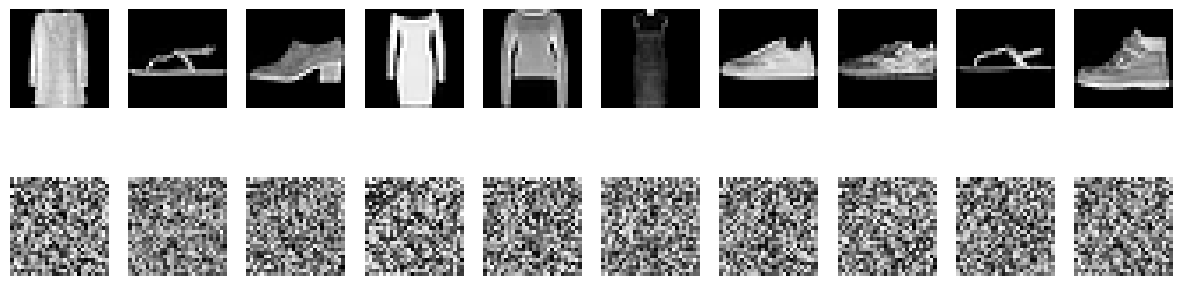

100%|█████████████████████████████████████████████████████████████| 938/938 [00:56<00:00, 16.63it/s]


Epoch [1/300], Loss: 21365.8872



100%|█████████████████████████████████████████████████████████████| 938/938 [00:55<00:00, 16.97it/s]


Epoch [2/300], Loss: 18487.6900



100%|█████████████████████████████████████████████████████████████| 938/938 [00:51<00:00, 18.09it/s]


...

100%|█████████████████████████████████████████████████████████████| 938/938 [00:51<00:00, 18.19it/s]


Epoch [8/300], Loss: 17324.3506



100%|█████████████████████████████████████████████████████████████| 938/938 [00:51<00:00, 18.29it/s]


Epoch [9/300], Loss: 17202.1437



100%|█████████████████████████████████████████████████████████████| 938/938 [00:51<00:00, 18.16it/s]


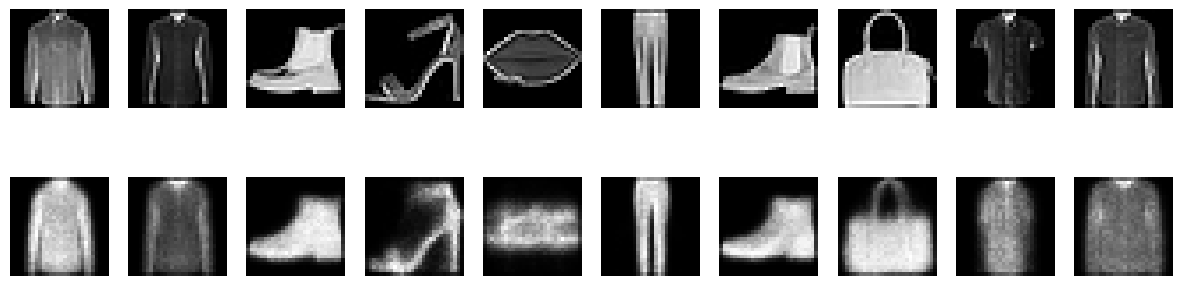

Epoch [10/300], Loss: 17085.3843



100%|█████████████████████████████████████████████████████████████| 938/938 [00:51<00:00, 18.11it/s]


Epoch [11/300], Loss: 16959.5604



100%|█████████████████████████████████████████████████████████████| 938/938 [00:51<00:00, 18.30it/s]


Epoch [12/300], Loss: 16847.0717



...

100%|█████████████████████████████████████████████████████████████| 938/938 [00:51<00:00, 18.17it/s]


Epoch [18/300], Loss: 16261.3674



100%|█████████████████████████████████████████████████████████████| 938/938 [00:51<00:00, 18.22it/s]


Epoch [19/300], Loss: 16193.7189



100%|█████████████████████████████████████████████████████████████| 938/938 [00:51<00:00, 18.30it/s]


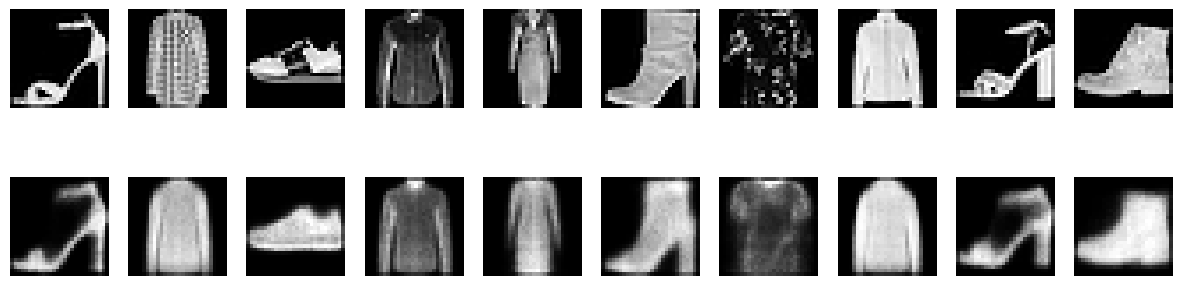

Epoch [20/300], Loss: 16125.3721



100%|█████████████████████████████████████████████████████████████| 938/938 [00:51<00:00, 18.17it/s]


Epoch [21/300], Loss: 16075.2186



100%|█████████████████████████████████████████████████████████████| 938/938 [00:51<00:00, 18.21it/s]


Epoch [22/300], Loss: 16025.6713



...

100%|█████████████████████████████████████████████████████████████| 938/938 [00:51<00:00, 18.22it/s]


Epoch [28/300], Loss: 15822.4349



100%|█████████████████████████████████████████████████████████████| 938/938 [00:51<00:00, 18.28it/s]


Epoch [29/300], Loss: 15798.4060



100%|█████████████████████████████████████████████████████████████| 938/938 [00:51<00:00, 18.30it/s]


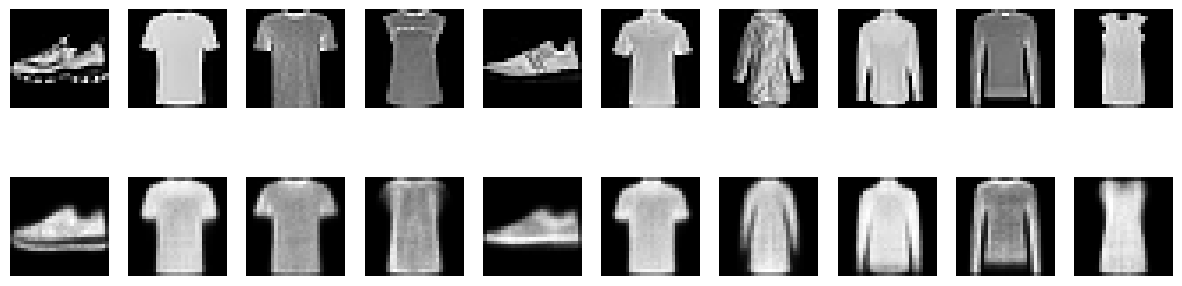

Epoch [30/300], Loss: 15775.1566



100%|█████████████████████████████████████████████████████████████| 938/938 [00:51<00:00, 18.18it/s]


Epoch [31/300], Loss: 15753.8000



100%|█████████████████████████████████████████████████████████████| 938/938 [00:51<00:00, 18.19it/s]


Epoch [32/300], Loss: 15736.2666



...

100%|█████████████████████████████████████████████████████████████| 938/938 [00:55<00:00, 16.83it/s]


Epoch [38/300], Loss: 15634.0831



100%|█████████████████████████████████████████████████████████████| 938/938 [00:55<00:00, 16.80it/s]


Epoch [39/300], Loss: 15618.4328



100%|█████████████████████████████████████████████████████████████| 938/938 [00:56<00:00, 16.46it/s]


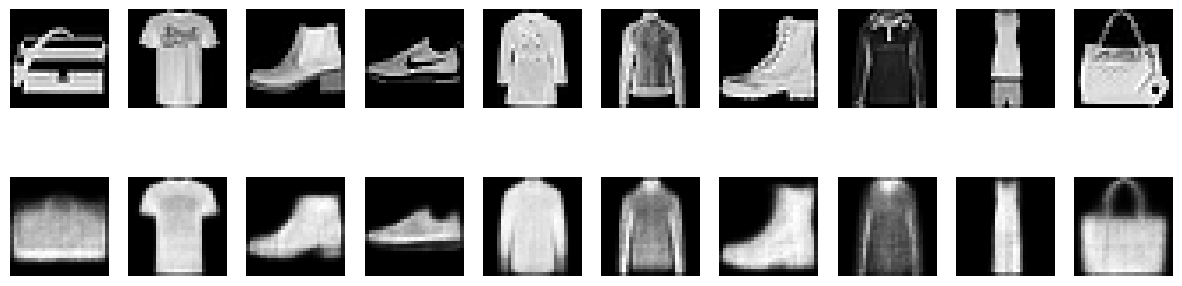

Epoch [40/300], Loss: 15609.0181



100%|█████████████████████████████████████████████████████████████| 938/938 [00:57<00:00, 16.34it/s]


Epoch [41/300], Loss: 15592.5638



100%|█████████████████████████████████████████████████████████████| 938/938 [00:57<00:00, 16.36it/s]


Epoch [42/300], Loss: 15579.7448



...

100%|█████████████████████████████████████████████████████████████| 938/938 [01:08<00:00, 13.76it/s]


Epoch [48/300], Loss: 15512.9304



100%|█████████████████████████████████████████████████████████████| 938/938 [01:08<00:00, 13.76it/s]


Epoch [49/300], Loss: 15503.9500



100%|█████████████████████████████████████████████████████████████| 938/938 [01:08<00:00, 13.77it/s]


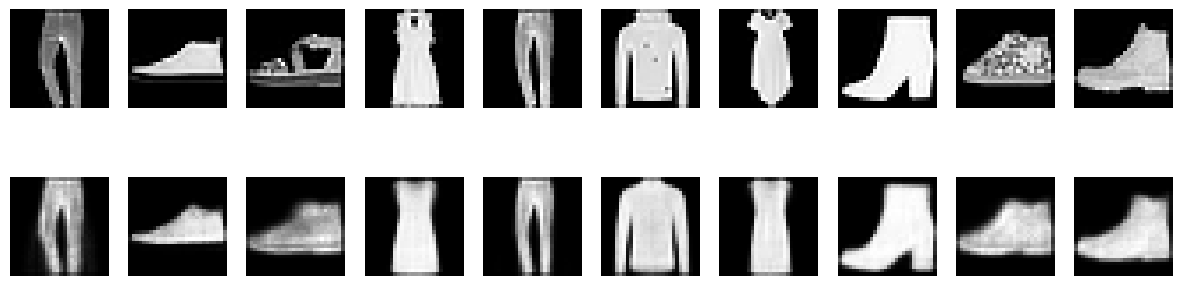

Epoch [50/300], Loss: 15493.6773



100%|█████████████████████████████████████████████████████████████| 938/938 [01:08<00:00, 13.74it/s]


Epoch [51/300], Loss: 15487.1830



100%|█████████████████████████████████████████████████████████████| 938/938 [01:08<00:00, 13.76it/s]


Epoch [52/300], Loss: 15474.8281



...

100%|█████████████████████████████████████████████████████████████| 938/938 [01:07<00:00, 13.81it/s]


Epoch [58/300], Loss: 15427.1143



100%|█████████████████████████████████████████████████████████████| 938/938 [01:07<00:00, 13.83it/s]


Epoch [59/300], Loss: 15421.8703



100%|█████████████████████████████████████████████████████████████| 938/938 [01:07<00:00, 13.81it/s]


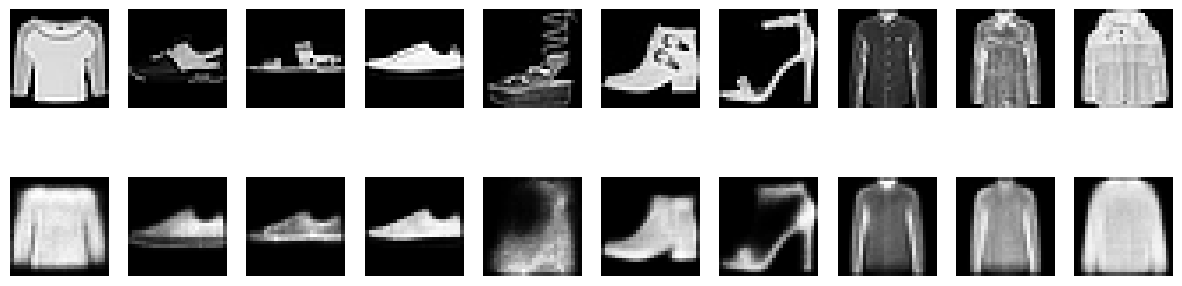

Epoch [60/300], Loss: 15414.0629



100%|█████████████████████████████████████████████████████████████| 938/938 [01:08<00:00, 13.74it/s]


Epoch [61/300], Loss: 15406.6390



100%|█████████████████████████████████████████████████████████████| 938/938 [01:07<00:00, 13.84it/s]


Epoch [62/300], Loss: 15400.1783



...

100%|█████████████████████████████████████████████████████████████| 938/938 [00:54<00:00, 17.16it/s]


Epoch [68/300], Loss: 15362.8132



100%|█████████████████████████████████████████████████████████████| 938/938 [00:54<00:00, 17.24it/s]


Epoch [69/300], Loss: 15359.4592



100%|█████████████████████████████████████████████████████████████| 938/938 [00:55<00:00, 17.05it/s]


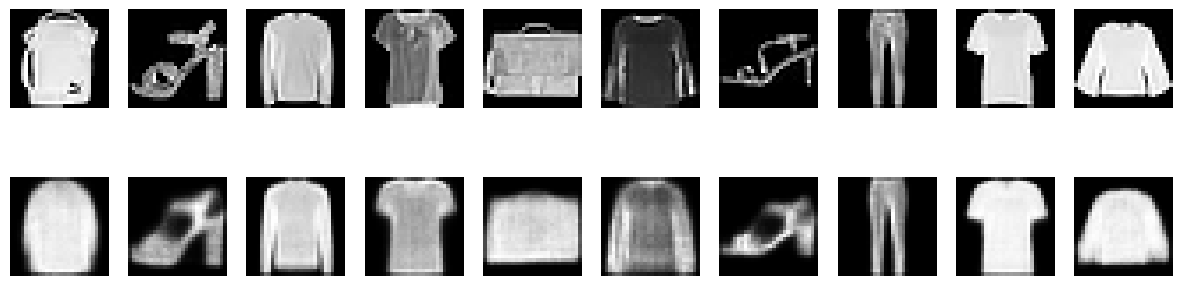

Epoch [70/300], Loss: 15350.9221



100%|█████████████████████████████████████████████████████████████| 938/938 [00:55<00:00, 16.80it/s]


Epoch [71/300], Loss: 15345.7124



100%|█████████████████████████████████████████████████████████████| 938/938 [00:55<00:00, 16.82it/s]


Epoch [72/300], Loss: 15342.5578



...

100%|█████████████████████████████████████████████████████████████| 938/938 [00:55<00:00, 17.02it/s]


Epoch [78/300], Loss: 15313.2996



100%|█████████████████████████████████████████████████████████████| 938/938 [00:56<00:00, 16.54it/s]


Epoch [79/300], Loss: 15309.9123



100%|█████████████████████████████████████████████████████████████| 938/938 [00:56<00:00, 16.59it/s]


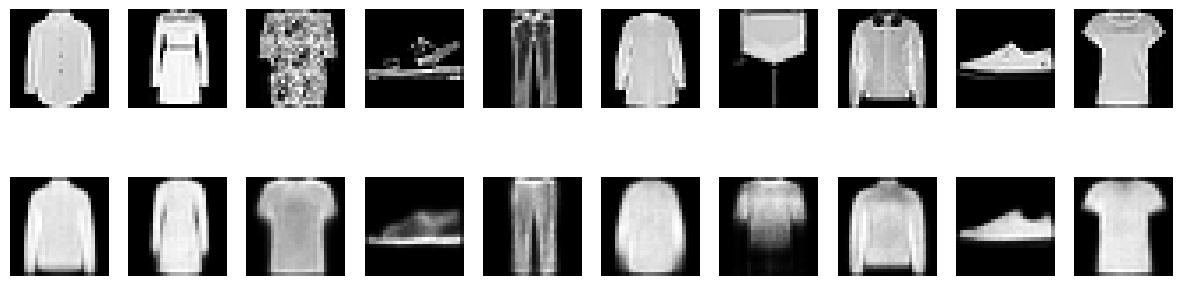

Epoch [80/300], Loss: 15308.3925



100%|█████████████████████████████████████████████████████████████| 938/938 [00:57<00:00, 16.35it/s]


Epoch [81/300], Loss: 15301.0857



100%|█████████████████████████████████████████████████████████████| 938/938 [00:57<00:00, 16.36it/s]


Epoch [82/300], Loss: 15299.3899



...

100%|█████████████████████████████████████████████████████████████| 938/938 [00:55<00:00, 16.77it/s]


Epoch [88/300], Loss: 15277.0265



100%|█████████████████████████████████████████████████████████████| 938/938 [00:55<00:00, 16.88it/s]


Epoch [89/300], Loss: 15274.6854



100%|█████████████████████████████████████████████████████████████| 938/938 [00:57<00:00, 16.30it/s]


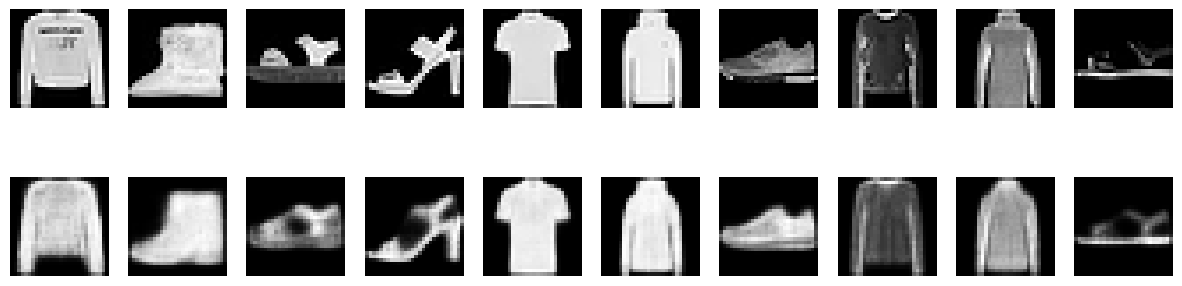

Epoch [90/300], Loss: 15269.3206



100%|█████████████████████████████████████████████████████████████| 938/938 [00:57<00:00, 16.26it/s]


Epoch [91/300], Loss: 15267.7920



100%|█████████████████████████████████████████████████████████████| 938/938 [00:57<00:00, 16.26it/s]


Epoch [92/300], Loss: 15262.9438



...

100%|█████████████████████████████████████████████████████████████| 938/938 [00:53<00:00, 17.47it/s]


Epoch [98/300], Loss: 15244.6516



100%|█████████████████████████████████████████████████████████████| 938/938 [00:56<00:00, 16.52it/s]


Epoch [99/300], Loss: 15240.1520



100%|█████████████████████████████████████████████████████████████| 938/938 [00:56<00:00, 16.57it/s]


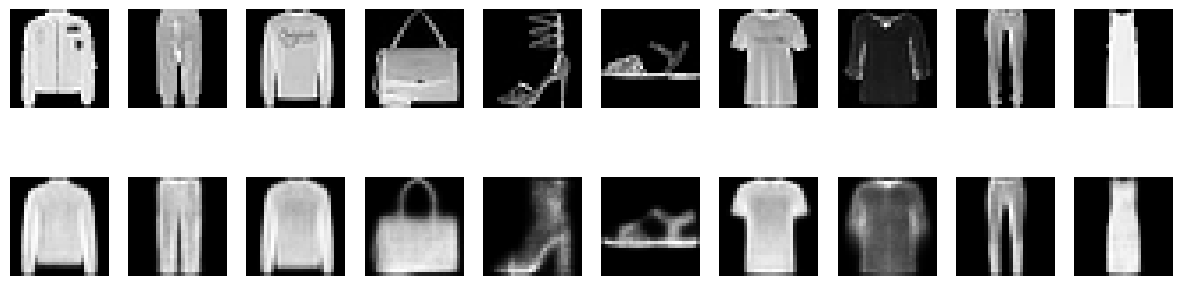

Epoch [100/300], Loss: 15238.2790



 24%|██████████████▌                                              | 224/938 [00:13<00:44, 16.05it/s]


KeyboardInterrupt: 

In [14]:
num_epochs = 300

vae.to(device)
optimizer = Adam(vae.parameters(), lr=0.0001)
vae_train_loss = []
test_f(train_loader, vae)

for epoch in range(num_epochs):
    train_l = train_f(train_loader, vae, optimizer)
    vae_train_loss.append(train_l)

    if (epoch + 1) % 10 == 0:
        test_f(train_loader, vae)

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {train_l:.4f}\n')

    if (epoch + 1) % 50 == 0:
        torch.save(vae.state_dict(), f'vae{epoch+1}.pth')

torch.save(vae.state_dict(), 'vae_final.pth')

##### Results

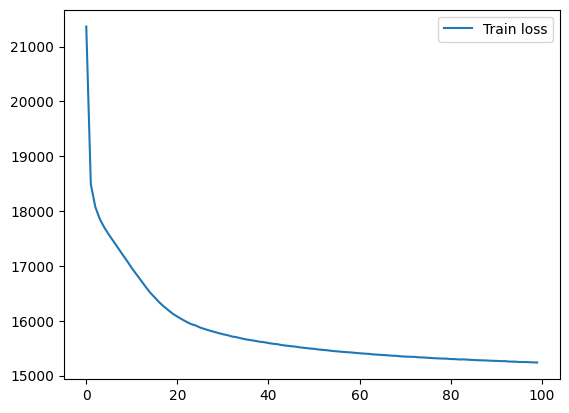

In [15]:
plt.plot(vae_train_loss, label = 'Train loss')
plt.legend()